# Stock Market Analysis_The Dow Jones Industrial Average (DJIA)

## Import libraries

In [97]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from scipy.optimize import minimize

## Load the raw dataset from yfinance

In [83]:
# Download raw Dow Jones Industrial Average (^DJI) data
raw_data = yf.download("^DJI", start="2020-01-01", end="2026-07-30")

# Inspect the raw dataset
# Option 2: Print top 5 and bottom 5 independently
print("--- First 5 Rows ---")
print(raw_data.head(5))

print("\n--- Last 5 Rows ---")
print(raw_data.tail(5))

[*********************100%***********************]  1 of 1 completed

--- First 5 Rows ---
Price              Close          High           Low          Open     Volume
Ticker              ^DJI          ^DJI          ^DJI          ^DJI       ^DJI
Date                                                                         
2020-01-02  28868.800781  28872.800781  28627.769531  28638.970703  251820000
2020-01-03  28634.880859  28716.310547  28500.359375  28553.330078  239590000
2020-01-06  28703.380859  28708.019531  28418.630859  28465.500000  252760000
2020-01-07  28583.679688  28685.500000  28565.279297  28639.179688  258900000
2020-01-08  28745.089844  28866.179688  28522.509766  28556.140625  291750000

--- Last 5 Rows ---
Price              Close          High           Low          Open     Volume
Ticker              ^DJI          ^DJI          ^DJI          ^DJI       ^DJI
Date                                                                         
2026-07-23  51711.648438  51885.140625  51542.058594  51755.539062  496570000
2026-07-24  51947.2500

## Clean and Prepare for stockmarket analysis

In [84]:
# 1. Flatten MultiIndex columns (common in modern yfinance)
df = raw_data.copy()
if isinstance(df.columns, pd.MultiIndex):
    # Flatten multi-level headers to single level (e.g., ('Close', '^DJI') -> 'Close')
    df.columns = [col[0] for col in df.columns]

# 2. Fix Datetime Index & Enforce Regular Business Day Frequency ('B')
df.index = pd.to_datetime(df.index)
df = df.asfreq("B")  # Fills missing weekend/holiday dates with NaNs to align time series

# 3. Handle Missing Values (Holidays / Non-trading days)
# Forward-fill up to 3 non-trading days, then backward-fill leading NaNs
df = df.ffill(limit=3).bfill()

# 4. Feature Engineering for Stock Market Analysis
# Stationary Daily Log Returns (Essential for modeling)
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

# Simple Moving Averages (Trend indicators)
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

# Annualized Rolling Volatility (30-day window)
df["Volatility_30D"] = df["Log_Return"].rolling(window=30).std() * np.sqrt(252)

# Daily Trading Range (%)
df["Daily_Range_Pct"] = ((df["High"] - df["Low"]) / df["Low"]) * 100

# 5. Clean Final Dataset (Remove initial NaN rows created by rolling windows)
df_clean = df.dropna().copy()

print("Dataset prepared successfully for analysis!")
print(f"Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} features")
display(df_clean.head())

Dataset prepared successfully for analysis!
Shape: 1516 rows, 10 features


,Close,High,Low,Open,Volume,Log_Return,SMA_50,SMA_200,Volatility_30D,Daily_Range_Pct
Date,,,,,,,,,,
2020-10-07,28303.460938,28369.660156,27971.359375,27971.359375,328750000.0,0.018928,27744.997813,26210.472871,0.201264,1.423959
2020-10-08,28425.509766,28459.130859,28265.560547,28348.859375,314750000.0,0.004303,27787.235000,26208.256416,0.200972,0.684827
2020-10-09,28586.900391,28676.289062,28440.630859,28533.609375,324050000.0,0.005662,27830.406602,26208.016514,0.200974,0.828597
2020-10-12,28837.519531,28957.900391,28659.669922,28671.119141,493680000.0,0.008729,27873.868984,26208.687207,0.201149,1.040593
2020-10-13,28679.810547,28808.839844,28604.349609,28764.949219,526110000.0,-0.005484,27910.895781,26209.167861,0.200710,0.714892


## The framework applied to conduct a professional stock market analysis

### 1. Top-Down Macroeconomic & Sector Analysis

[*********************100%***********************]  13 of 13 completed



TOP-DOWN MACROECONOMIC ENVIRONMENT OVERVIEW


,Latest Price / Yield,1-Month Change (%),1-Year Change (%)
Ticker,,,
10-Yr Yield,4.70,3.59,8.69
Crude Oil,82.49,0.00,31.35
VIX (Volatility),15.02,-19.98,-0.46
S&P 500,7775.05,4.26,20.55
US Dollar Index,99.43,-1.31,1.61



SECTOR PERFORMANCE MATRIX


,3M Return (%),6M Return (%),1Y Return (%),YTD Return (%)
Ticker,,,,
Energy,3.36,17.26,49.85,38.07
Technology,9.53,37.09,44.34,32.51
Industrials,9.53,7.12,25.61,18.71
Healthcare,15.31,7.21,24.96,8.49
Financials,12.72,12.31,12.51,6.72
Utilities,0.75,-3.88,5.62,3.24
Consumer Discretionary,1.09,1.54,3.27,-0.44
Communication Services,-3.86,-1.38,1.88,-3.49


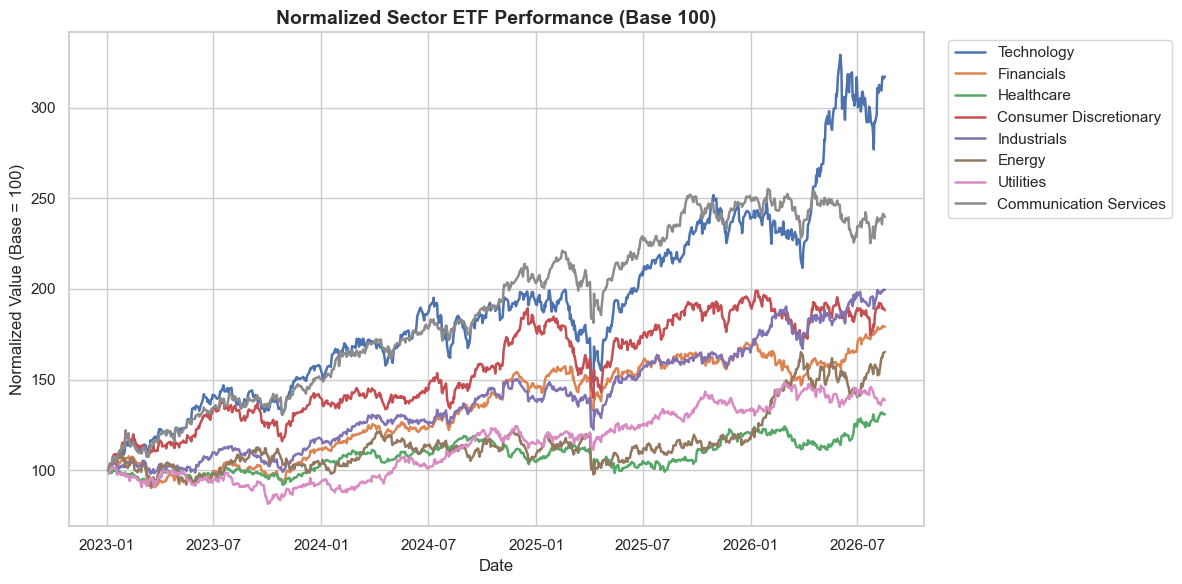

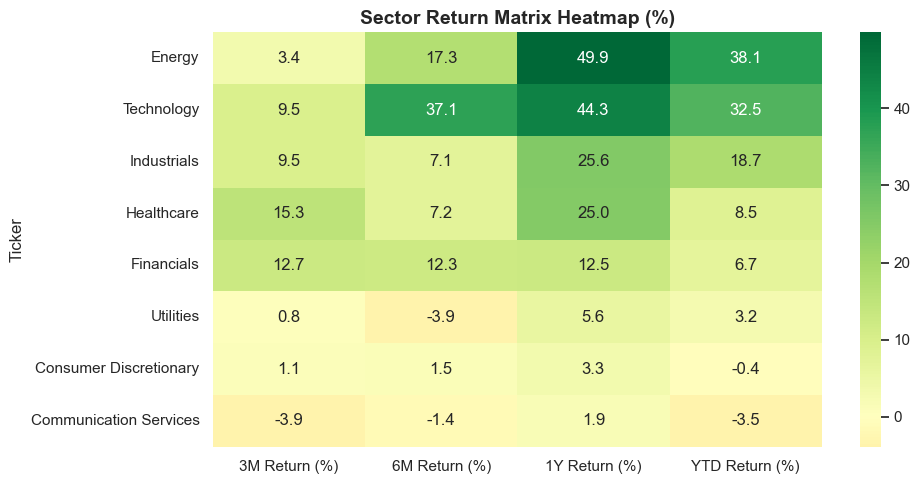

In [92]:
# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# 1. DEFINE MACRO & SECTOR TICKERS
# Macro Assets: 10-Yr Treasury Yield, WTI Crude Oil, VIX, S&P 500, US Dollar Index
macro_tickers = {
    "10-Yr Yield": "^TNX",
    "Crude Oil": "CL=F",
    "VIX (Volatility)": "^VIX",
    "S&P 500": "^GSPC",
    "US Dollar Index": "DX-Y.NYB",
}

# Sector SPDR ETFs representing major US market sectors
sector_tickers = {
    "Technology": "XLK",
    "Financials": "XLF",
    "Healthcare": "XLV",
    "Consumer Discretionary": "XLY",
    "Industrials": "XLI",
    "Energy": "XLE",
    "Utilities": "XLU",
    "Communication Services": "XLC",
}

# Combine all tickers for single-batch download
all_tickers = {**macro_tickers, **sector_tickers}
start_date = "2023-01-01"

print("Downloading macro and sector data from Yahoo Finance...")
raw_data = yf.download(list(all_tickers.values()), start=start_date, auto_adjust=True)

# Flatten MultiIndex columns if necessary
if isinstance(raw_data.columns, pd.MultiIndex):
    data = raw_data["Close"] if "Close" in raw_data.columns.levels[0] else raw_data.iloc[:, 0]
else:
    data = raw_data

# Map ticker symbols back to human-readable names
rename_map = {v: k for k, v in all_tickers.items()}
data = data.rename(columns=rename_map).ffill().dropna()

# 2. MACRO INDICATORS DASHBOARD (Prints baseline summary metrics)
latest_macro = pd.DataFrame(
    {
        "Latest Price / Yield": data[list(macro_tickers.keys())].iloc[-1],
        "1-Month Change (%)": data[list(macro_tickers.keys())].pct_change(21).iloc[-1]
        * 100,
        "1-Year Change (%)": data[list(macro_tickers.keys())].pct_change(252).iloc[-1]
        * 100,
    }
)

print("\n" + "=" * 50)
print("TOP-DOWN MACROECONOMIC ENVIRONMENT OVERVIEW")
print("=" * 50)
display(latest_macro.round(2))

# 3. SECTOR PERFORMANCE & RELATIVE STRENGTH ANALYSIS
sector_df = data[list(sector_tickers.keys())]

# Calculate 3-Month, 6-Month, and 1-Year Total Returns
sector_perf = pd.DataFrame(
    {
        "3M Return (%)": sector_df.pct_change(63).iloc[-1] * 100,
        "6M Return (%)": sector_df.pct_change(126).iloc[-1] * 100,
        "1Y Return (%)": sector_df.pct_change(252).iloc[-1] * 100,
        "YTD Return (%)": (
            sector_df.iloc[-1]
            / sector_df.loc[sector_df.index.year == sector_df.index[-1].year].iloc[
                0
            ]
            - 1
        )
        * 100,
    }
).sort_values(by="1Y Return (%)", ascending=False)

print("\n" + "=" * 50)
print("SECTOR PERFORMANCE MATRIX")
print("=" * 50)
display(sector_perf.round(2))

# 4. VISUALIZATION: SECTOR HEATMAP & RELATIVE PERFORMANCE
# Normalize sector prices to 100 for visual comparison
sector_normalized = (sector_df / sector_df.iloc[0]) * 100

plt.figure(figsize=(12, 6))
for column in sector_normalized.columns:
    plt.plot(
        sector_normalized.index,
        sector_normalized[column],
        label=column,
        linewidth=1.8,
    )

plt.title(
    "Normalized Sector ETF Performance (Base 100)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Normalized Value (Base = 100)")
plt.xlabel("Date")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Heatmap of Sector Returns
plt.figure(figsize=(10, 5))
sns.heatmap(sector_perf, annot=True, fmt=".1f", cmap="RdYlGn", center=0, cbar=True)
plt.title("Sector Return Matrix Heatmap (%)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2. Fundamental & Quantitative Equity Valuation

In [93]:
# 1. PARAMETERS & INPUT DATA (e.g., Apple Inc. - AAPL)
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# Market Inputs
risk_free_rate = 0.0425  # 10-Year Treasury Yield (~4.25%)
market_return = 0.095  # Expected Market Return (~9.5%)
equity_risk_premium = market_return - risk_free_rate

# Fetch Financial Data
info = ticker.info
beta = info.get("beta", 1.2)
current_price = info.get("currentPrice", info.get("regularMarketPrice", 0))
shares_outstanding = info.get("sharesOutstanding", 0)
total_debt = info.get("totalDebt", 0)
total_cash = info.get("totalCash", 0)
ebitda = info.get("ebitda", 0)

# Historical Free Cash Flow Baseline
free_cash_flow = info.get("freeCashflow")
if not free_cash_flow:
    # Fallback: Cash from Operations - Capital Expenditures
    cash_flow = ticker.cashflow
    fcf_series = (
        cash_flow.loc["Operating Cash Flow"]
        + cash_flow.loc["Capital Expenditure"]
    )
    free_cash_flow = fcf_series.iloc[0]

# 2. INTRINSIC VALUATION: WACC & DCF MODELING
# Capital Structure Weights
market_cap = current_price * shares_outstanding
total_capital = market_cap + total_debt
weight_equity = market_cap / total_capital
weight_debt = total_debt / total_capital

# Cost of Equity (CAPM)
cost_of_equity = risk_free_rate + beta * equity_risk_premium

# Cost of Debt (Approximate)
interest_expense = info.get("interestExpense", 0)
cost_of_debt = (
    abs(interest_expense) / total_debt if total_debt > 0 else risk_free_rate
)
tax_rate = 0.21  # Standard US Corporate Tax Rate

# Weighted Average Cost of Capital (WACC)
wacc = (weight_equity * cost_of_equity) + (
    weight_debt * cost_of_debt * (1 - tax_rate)
)


def run_dcf(
    base_fcf,
    growth_rate,
    terminal_growth,
    discount_rate,
    projection_years=5,
):
    """Calculates Implied Share Price using a 2-Stage FCFF Model."""
    # Stage 1: Projected Cash Flows
    projected_fcf = [
        base_fcf * ((1 + growth_rate) ** i)
        for i in range(1, projection_years + 1)
    ]
    pv_fcf = sum(
        [
            fcf / ((1 + discount_rate) ** i)
            for i, fcf in enumerate(projected_fcf, start=1)
        ]
    )

    # Stage 2: Terminal Value (Gordon Growth Model)
    terminal_value = (projected_fcf[-1] * (1 + terminal_growth)) / (
        discount_rate - terminal_growth
    )
    pv_terminal_value = terminal_value / ((1 + discount_rate) ** projection_years)

    # Enterprise Value to Equity Value
    enterprise_value = pv_fcf + pv_terminal_value
    equity_value = enterprise_value + total_cash - total_debt
    implied_share_price = equity_value / shares_outstanding

    return implied_share_price


# Base Case Valuation
base_growth_rate = 0.08  # Projected FCF growth rate
base_terminal_growth = 0.025  # Terminal GDP growth rate
implied_price_base = run_dcf(
    free_cash_flow, base_growth_rate, base_terminal_growth, wacc
)

# 3. SCENARIO & SENSITIVITY ANALYSIS
scenarios = {
    "Bear Case": {
        "Growth": base_growth_rate - 0.03,
        "WACC": wacc + 0.01,
        "Terminal": 0.02,
    },
    "Base Case": {
        "Growth": base_growth_rate,
        "WACC": wacc,
        "Terminal": base_terminal_growth,
    },
    "Bull Case": {
        "Growth": base_growth_rate + 0.03,
        "WACC": wacc - 0.01,
        "Terminal": 0.03,
    },
}

scenario_results = {}
for name, params in scenarios.items():
    price = run_dcf(
        free_cash_flow, params["Growth"], params["Terminal"], params["WACC"]
    )
    upside = ((price - current_price) / current_price) * 100
    scenario_results[name] = {
        "FCF Growth": f"{params['Growth']:.1%}",
        "WACC": f"{params['WACC']:.2%}",
        "Terminal Growth": f"{params['Terminal']:.1%}",
        "Implied Price": f"${price:.2f}",
        "Upside / Downside": f"{upside:+.1f}%",
    }

# 4. RELATIVE VALUATION (PEERS MULTIPLES ANALYSIS)
peers = ["MSFT", "GOOGL", "AAPL", "AMZN"]
peer_data = []

for peer in peers:
    p_info = yf.Ticker(peer).info
    peer_data.append(
        {
            "Ticker": peer,
            "Trailing P/E": p_info.get("trailingPE"),
            "Forward P/E": p_info.get("forwardPE"),
            "EV/EBITDA": p_info.get("enterpriseToEbitda"),
            "P/B Ratio": p_info.get("priceToBook"),
            "PEG Ratio": p_info.get("pegRatio"),
        }
    )

peers_df = pd.DataFrame(peer_data).set_index("Ticker")

# 5. OUTPUT DISPLAY
print("=" * 60)
print(f"VALUATION SUMMARY: {ticker_symbol}")
print("=" * 60)
print(f"Current Market Price:       ${current_price:.2f}")
print(f"Cost of Equity (CAPM):      {cost_of_equity:.2%}")
print(f"Calculated WACC:            {wacc:.2%}")
print(
    f"Base Case DCF Fair Value:   ${implied_price_base:.2f} (Upside: {((implied_price_base - current_price)/current_price)*100:+.1f}%)"
)

print("\n" + "-" * 60)
print("SCENARIO ANALYSIS")
print("-" * 60)
display(pd.DataFrame(scenario_results).T)

print("\n" + "-" * 60)
print("RELATIVE MULTIPLES BENCHMARKING")
print("-" * 60)
display(peers_df.round(2))

VALUATION SUMMARY: AAPL
Current Market Price:       $304.94
Cost of Equity (CAPM):      9.95%
Calculated WACC:            9.77%
Base Case DCF Fair Value:   $129.66 (Upside: -57.5%)

------------------------------------------------------------
SCENARIO ANALYSIS
------------------------------------------------------------


,FCF Growth,WACC,Terminal Growth,Implied Price,Upside / Downside
Bear Case,5.0%,10.77%,2.0%,$95.76,-68.6%
Base Case,8.0%,9.77%,2.5%,$129.66,-57.5%
Bull Case,11.0%,8.77%,3.0%,$183.69,-39.8%



------------------------------------------------------------
RELATIVE MULTIPLES BENCHMARKING
------------------------------------------------------------


,Trailing P/E,Forward P/E,EV/EBITDA,P/B Ratio,PEG Ratio
Ticker,,,,,
MSFT,27.05,20.57,19.21,8.14,1.61
GOOGL,17.31,23.38,23.83,6.77,0.94
AAPL,34.97,32.07,26.71,41.43,2.47
AMZN,21.06,25.15,17.53,5.11,1.40


#### A. Intrinsic Valuation (DCF Modeling)

In [94]:
# 1. DISCOUNT RATE CALIBRATION (WACC via CAPM)
def calculate_wacc(
    risk_free_rate,
    beta,
    market_return,
    cost_of_debt,
    tax_rate,
    market_cap,
    total_debt,
):
    """Calculates the Weighted Average Cost of Capital (WACC)."""
    # Capital Structure Weights
    total_capital = market_cap + total_debt
    w_e = market_cap / total_capital
    w_d = total_debt / total_capital

    # Cost of Equity via CAPM: E(Ri) = Rf + Beta * (Em - Rf)
    equity_risk_premium = market_return - risk_free_rate
    cost_of_equity = risk_free_rate + (beta * equity_risk_premium)

    # After-Tax Cost of Debt
    after_tax_cost_of_debt = cost_of_debt * (1 - tax_rate)

    # WACC Formula
    wacc = (w_e * cost_of_equity) + (w_d * after_tax_cost_of_debt)

    return wacc, cost_of_equity


# 2. FREE CASH FLOW PROJECTION & DCF MODEL
def run_dcf_model(
    base_revenue,
    rev_growth_rates,  # List of growth rates for projected years
    operating_margins,  # List of operating margins per year
    tax_rate,
    capex_pct_rev,  # Capex as % of Revenue
    nwc_pct_rev,  # Change in Net Working Capital as % of Revenue
    discount_rate,
    terminal_growth_rate,
    cash,
    debt,
    shares_outstanding,
):
    """Builds a multi-year FCFF projection model and calculates implied share price."""
    years = len(rev_growth_rates)
    revenues = []
    ebit_list = []
    fcf_list = []
    pv_fcf_list = []

    current_rev = base_revenue

    # Project Cash Flows
    for i in range(years):
        current_rev *= 1 + rev_growth_rates[i]
        ebit = current_rev * operating_margins[i]
        ebiat = ebit * (1 - tax_rate)  # Earnings Before Interest After Tax

        # Reinvestment
        capex = current_rev * capex_pct_rev
        delta_nwc = current_rev * nwc_pct_rev

        # FCFF = EBIAT - Capex - Change in NWC (assuming D&A roughly offsets baseline maintenance Capex)
        fcff = ebiat - capex - delta_nwc

        # Present Value
        discount_factor = (1 + discount_rate) ** (i + 1)
        pv_fcf = fcff / discount_factor

        revenues.append(current_rev)
        ebit_list.append(ebit)
        fcf_list.append(fcff)
        pv_fcf_list.append(pv_fcf)

    # Terminal Value Calculation (Gordon Growth Model)
    terminal_value = (fcf_list[-1] * (1 + terminal_growth_rate)) / (
        discount_rate - terminal_growth_rate
    )
    pv_terminal_value = terminal_value / ((1 + discount_rate) ** years)

    # Valuation Sums
    enterprise_value = sum(pv_fcf_list) + pv_terminal_value
    equity_value = enterprise_value + cash - debt
    implied_share_price = equity_value / shares_outstanding

    # Compile DataFrame
    projection_df = pd.DataFrame(
        {
            "Revenue": revenues,
            "EBIT": ebit_list,
            "FCFF": fcf_list,
            "PV of FCFF": pv_fcf_list,
        },
        index=[f"Year {i+1}" for i in range(years)],
    )

    return implied_share_price, enterprise_value, pv_terminal_value, projection_df


# 3. BASELINE INPUT PARAMETERS & EXECUTION
# Market & Company Inputs
rf = 0.0425  # 10-Year Treasury Yield (4.25%)
e_rm = 0.095  # Expected Market Return (9.50%)
beta_val = 1.15
cost_debt_val = 0.055
tax_rate_val = 0.21

mcap_val = 2_500_000_000_000  # $2.5T Market Cap
debt_val = 100_000_000_000  # $100B Total Debt
cash_val = 60_000_000_000  # $60B Cash
shares_val = 15_000_000_000  # 15B Shares Outstanding
current_price = 175.00

# Calculate WACC
wacc_baseline, ke = calculate_wacc(
    risk_free_rate=rf,
    beta=beta_val,
    market_return=e_rm,
    cost_of_debt=cost_debt_val,
    tax_rate=tax_rate_val,
    market_cap=mcap_val,
    total_debt=debt_val,
)

# 5-Year Projection Inputs
base_rev = 380_000_000_000
growth_rates = [0.08, 0.08, 0.07, 0.06, 0.05]
margins = [0.30, 0.30, 0.31, 0.31, 0.32]
g_terminal = 0.025

price_base, ev_base, pv_tv_base, df_proj = run_dcf_model(
    base_revenue=base_rev,
    rev_growth_rates=growth_rates,
    operating_margins=margins,
    tax_rate=tax_rate_val,
    capex_pct_rev=0.05,
    nwc_pct_rev=0.01,
    discount_rate=wacc_baseline,
    terminal_growth_rate=g_terminal,
    cash=cash_val,
    debt=debt_val,
    shares_outstanding=shares_val,
)

print(f"Calculated WACC: {wacc_baseline:.2%}")
print(f"Base Case Implied Share Price: ${price_base:.2f}\n")
display(df_proj.round(2))

# 4. SCENARIO & STRESS-TEST ANALYSIS (Bear, Base, Bull)
scenarios = {
    "Bear Case": {
        "Growth_Adj": -0.03,
        "Margin_Adj": -0.02,
        "WACC_Adj": 0.01,
        "Terminal_g": 0.020,
    },
    "Base Case": {
        "Growth_Adj": 0.00,
        "Margin_Adj": 0.00,
        "WACC_Adj": 0.00,
        "Terminal_g": g_terminal,
    },
    "Bull Case": {
        "Growth_Adj": 0.03,
        "Margin_Adj": 0.02,
        "WACC_Adj": -0.01,
        "Terminal_g": 0.030,
    },
}

scenario_summary = []

for name, s in scenarios.items():
    adj_growth = [g + s["Growth_Adj"] for g in growth_rates]
    adj_margins = [m + s["Margin_Adj"] for m in margins]
    adj_wacc = wacc_baseline + s["WACC_Adj"]

    implied_p, _, _, _ = run_dcf_model(
        base_revenue=base_rev,
        rev_growth_rates=adj_growth,
        operating_margins=adj_margins,
        tax_rate=tax_rate_val,
        capex_pct_rev=0.05,
        nwc_pct_rev=0.01,
        discount_rate=adj_wacc,
        terminal_growth_rate=s["Terminal_g"],
        cash=cash_val,
        debt=debt_val,
        shares_outstanding=shares_val,
    )

    upside = ((implied_p - current_price) / current_price) * 100

    scenario_summary.append(
        {
            "Scenario": name,
            "Discount Rate (WACC)": f"{adj_wacc:.2%}",
            "Terminal Growth Rate": f"{s['Terminal_g']:.2%}",
            "Avg Revenue Growth": f"{np.mean(adj_growth):.1%}",
            "Avg Operating Margin": f"{np.mean(adj_margins):.1%}",
            "Implied Share Price": f"${implied_p:.2f}",
            "Upside / Downside": f"{upside:+.1f}%",
        }
    )

print("\n" + "=" * 70)
print("SCENARIO & SENSITIVITY SUMMARY TABLE")
print("=" * 70)
display(pd.DataFrame(scenario_summary).set_index("Scenario"))

Calculated WACC: 10.06%
Base Case Implied Share Price: $75.83



,Revenue,EBIT,FCFF,PV of FCFF
Year 1,4.104000e+11,1.231200e+11,7.264080e+10,6.600172e+10
Year 2,4.432320e+11,1.329696e+11,7.845206e+10,6.476699e+10
Year 3,4.742582e+11,1.470201e+11,8.769035e+10,6.577726e+10
Year 4,5.027137e+11,1.558413e+11,9.295177e+10,6.335142e+10
Year 5,5.278494e+11,1.689118e+11,1.017694e+11,6.302174e+10



SCENARIO & SENSITIVITY SUMMARY TABLE


,Discount Rate (WACC),Terminal Growth Rate,Avg Revenue Growth,Avg Operating Margin,Implied Share Price,Upside / Downside
Scenario,,,,,,
Bear Case,11.06%,2.00%,3.8%,28.8%,$50.95,-70.9%
Base Case,10.06%,2.50%,6.8%,30.8%,$75.83,-56.7%
Bull Case,9.06%,3.00%,9.8%,32.8%,$116.35,-33.5%


#### B. Relative Valuation (Multiples Analysis)

In [95]:
# 3. COMPUTE BENCHMARK STATISTICS (PEER GROUP AVERAGE & MEDIAN)
# Filter peers DataFrame to numeric valuation metrics only
df_peers_only = df_multiples.loc[peer_tickers].select_dtypes(include=np.number)

# Extract target metrics as a numeric Series directly
target_metrics = pd.to_numeric(
    df_multiples.loc[target_ticker].drop("Company"), errors="coerce"
)

# Compute peer group summary statistics
peer_mean = df_peers_only.mean()
peer_median = df_peers_only.median()

# Create benchmark comparison table
benchmark_df = pd.DataFrame(
    {
        f"Target ({target_ticker})": target_metrics,
        "Peer Median": peer_median,
        "Peer Mean": peer_mean,
    }
)

# Calculate Premium / (Discount) % relative to Peer Median
premium_discount = (
    (benchmark_df[f"Target ({target_ticker})"] - benchmark_df["Peer Median"])
    / benchmark_df["Peer Median"]
) * 100

benchmark_df["Premium / (Discount) vs Median"] = premium_discount.apply(
    lambda x: f"{x:+.2f}%" if pd.notnull(x) else "N/A"
)

# 4. DISPLAY RESULTS
print("=" * 70)
print("PEER GROUP MULTIPLES SUMMARY TABLE")
print("=" * 70)
display(df_multiples.round(2))

print("\n" + "=" * 70)
print(f"BENCHMARKING SUMMARY: {target_ticker} vs. PEER GROUP MEDIAN")
print("=" * 70)
display(benchmark_df.round(2))

PEER GROUP MULTIPLES SUMMARY TABLE


,Company,Trailing P/E,Forward P/E,EV/EBITDA,P/B Ratio,PEG Ratio,EV/Revenue
Ticker,,,,,,,
AAPL,Apple Inc.,35.08,32.18,26.71,41.57,2.47,9.61
MSFT,Microsoft Corporation,27.63,21.02,19.21,8.32,1.61,11.24
GOOGL,Alphabet Inc.,17.36,23.46,23.83,6.80,0.94,9.26
AMZN,"Amazon.com, Inc.",21.15,25.25,17.53,5.13,1.40,3.82
META,"Meta Platforms, Inc.",22.22,16.91,13.90,5.75,0.88,6.68



BENCHMARKING SUMMARY: AAPL vs. PEER GROUP MEDIAN


,Target (AAPL),Peer Median,Peer Mean,Premium / (Discount) vs Median
Trailing P/E,35.08,21.69,22.09,+61.78%
Forward P/E,32.18,22.24,21.66,+44.71%
EV/EBITDA,26.71,18.37,18.62,+45.42%
P/B Ratio,41.57,6.27,6.50,+562.43%
PEG Ratio,2.47,1.17,1.21,+111.11%
EV/Revenue,9.61,7.97,7.75,+20.63%


## 3. Financial Engineering & Quantitative Risk Analytics

[*********************100%***********************]  6 of 6 completed


1. FACTOR ATTRIBUTION ANALYSIS (CAPM Framework)
Annualized Alpha (Jensen's Alpha): +6.33%
Portfolio Market Beta (β):         0.86
R-Squared (Market Explanatory Power): 75.88%
p-value for Alpha:                 0.0646

2. MARKOWITZ MEAN-VARIANCE OPTIMIZATION


,Current Weights,Optimal Tangency Weights
Asset,,
AAPL,0.25,0.1317
MSFT,0.25,0.0000
JPM,0.20,0.2175
XOM,0.15,0.3909
JNJ,0.15,0.2600


Current Portfolio:   Expected Return: 17.48%, Volatility: 16.39%, Sharpe Ratio: 0.81
Optimal Portfolio:   Expected Return: 20.95%, Volatility: 16.11%, Sharpe Ratio: 1.04

3. DOWNSIDE TAIL-RISK ANALYTICS ($10,000,000 Portfolio)


,Historical (% Return),Historical ($ Loss),Parametric (% Return),Parametric ($ Loss)
"Metric (1-Day, 95% Confidence)",,,,
Value at Risk (VaR),1.66%,"$166,339.45",1.63%,"$162,887.72"
Conditional VaR (CVaR / Tail Loss),2.35%,"$234,760.37",2.06%,"$206,029.95"


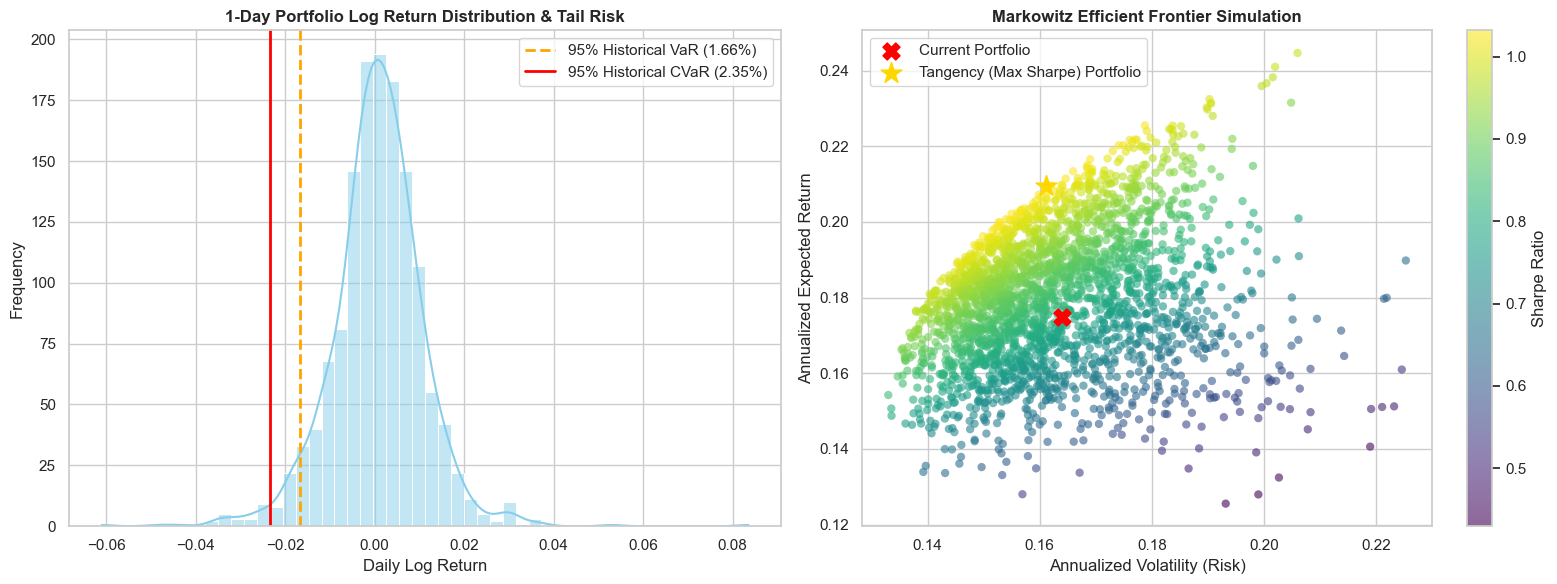

In [99]:
sns.set_theme(style="whitegrid")

# 1. DATA LOADING: PORTFOLIO & MARKET ASSETS
# Define Multi-Asset Portfolio Allocation (DJIA Component Subset)
portfolio_weights = {
    "AAPL": 0.25,
    "MSFT": 0.25,
    "JPM":  0.20,
    "XOM":  0.15,
    "JNJ":  0.15
}

tickers = list(portfolio_weights.keys())
weights = np.array(list(portfolio_weights.values()))
market_benchmark = "^GSPC"  # S&P 500 Market Benchmark
rf_rate_annual = 0.0425     # 10-Yr Treasury Yield (4.25%)
rf_daily = rf_rate_annual / 252

# Download Historical Daily Adjusted Close Prices
all_symbols = tickers + [market_benchmark]
raw_data = yf.download(all_symbols, start="2021-01-01", end="2026-07-30", auto_adjust=True)

# Process columns
if isinstance(raw_data.columns, pd.MultiIndex):
    prices = raw_data["Close"] if "Close" in raw_data.columns.levels[0] else raw_data.iloc[:, 0]
else:
    prices = raw_data

prices = prices.ffill().dropna()

# Compute Daily Log Returns
returns = np.log(prices / prices.shift(1)).dropna()
asset_returns = returns[tickers]
market_returns = returns[market_benchmark]

# Portfolio Daily Log Returns
portfolio_returns = (asset_returns * weights).sum(axis=1)

# ==============================================================================
# 2. FACTOR ATTRIBUTION MODELING (Single & Multi-Factor Regressions)
# ==============================================================================
# Capital Asset Pricing Model (CAPM) Benchmark Regression
X_capm = sm.add_constant(market_returns - rf_daily)
y_port = portfolio_returns - rf_daily

capm_model = sm.OLS(y_port, X_capm).fit()
alpha_daily = capm_model.params.iloc[0]
beta_market = capm_model.params.iloc[1]
r_squared = capm_model.rsquared

alpha_annualized = alpha_daily * 252

print("=" * 70)
print("1. FACTOR ATTRIBUTION ANALYSIS (CAPM Framework)")
print("=" * 70)
print(f"Annualized Alpha (Jensen's Alpha): {alpha_annualized:+.2%}")
print(f"Portfolio Market Beta (β):         {beta_market:.2f}")
print(f"R-Squared (Market Explanatory Power): {r_squared:.2%}")
print(f"p-value for Alpha:                 {capm_model.pvalues.iloc[0]:.4f}")

# ==============================================================================
# 3. PORTFOLIO OPTIMIZATION (Markowitz Mean-Variance Efficiency)
# ==============================================================================
mean_returns_annual = asset_returns.mean() * 252
cov_matrix_annual = asset_returns.cov() * 252

def portfolio_performance(w, mean_returns, cov_matrix):
    port_return = np.sum(mean_returns * w)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    return port_return, port_vol

def negative_sharpe(w, mean_returns, cov_matrix, rf):
    p_ret, p_vol = portfolio_performance(w, mean_returns, cov_matrix)
    return -(p_ret - rf) / p_vol

# Optimization Constraints & Bounds
num_assets = len(tickers)
args = (mean_returns_annual, cov_matrix_annual, rf_rate_annual)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Weights sum to 1
bounds = tuple((0.0, 1.0) for _ in range(num_assets))           # Long-only constraint

# Maximize Sharpe Ratio
init_guess = num_assets * [1.0 / num_assets,]
opt_sharpe = minimize(negative_sharpe, init_guess, args=args, method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = opt_sharpe.x
opt_ret, opt_vol = portfolio_performance(optimal_weights, mean_returns_annual, cov_matrix_annual)
opt_sharpe_ratio = (opt_ret - rf_rate_annual) / opt_vol

# Baseline Portfolio Stats
base_ret, base_vol = portfolio_performance(weights, mean_returns_annual, cov_matrix_annual)
base_sharpe_ratio = (base_ret - rf_rate_annual) / base_vol

opt_df = pd.DataFrame({
    "Asset": tickers,
    "Current Weights": weights,
    "Optimal Tangency Weights": optimal_weights
}).set_index("Asset")

print("\n" + "=" * 70)
print("2. MARKOWITZ MEAN-VARIANCE OPTIMIZATION")
print("=" * 70)
display(opt_df.round(4))
print(f"Current Portfolio:   Expected Return: {base_ret:.2%}, Volatility: {base_vol:.2%}, Sharpe Ratio: {base_sharpe_ratio:.2f}")
print(f"Optimal Portfolio:   Expected Return: {opt_ret:.2%}, Volatility: {opt_vol:.2%}, Sharpe Ratio: {opt_sharpe_ratio:.2f}")

# ==============================================================================
# 4. DOWNSIDE RISK MEASUREMENT (VaR & Conditional VaR / Expected Shortfall)
# ==============================================================================
portfolio_value = 10_000_000 # $10 Million Portfolio
confidence_level = 0.95

# A. Historical Simulation VaR & CVaR
sorted_returns = np.sort(portfolio_returns)
var_index = int((1 - confidence_level) * len(sorted_returns))

var_historical_pct = -sorted_returns[var_index]
cvar_historical_pct = -sorted_returns[:var_index].mean()

# B. Parametric Gaussian VaR & CVaR
port_daily_mean = portfolio_returns.mean()
port_daily_std = portfolio_returns.std()

z_score = stats.norm.ppf(confidence_level)
var_parametric_pct = (z_score * port_daily_std) - port_daily_mean
cvar_parametric_pct = (stats.norm.pdf(z_score) / (1 - confidence_level)) * port_daily_std - port_daily_mean

# Convert to Dollar Risk Exposure
risk_summary = pd.DataFrame({
    "Metric (1-Day, 95% Confidence)": ["Value at Risk (VaR)", "Conditional VaR (CVaR / Tail Loss)"],
    "Historical (% Return)": [f"{var_historical_pct:.2%}", f"{cvar_historical_pct:.2%}"],
    "Historical ($ Loss)": [f"${var_historical_pct * portfolio_value:,.2f}", f"${cvar_historical_pct * portfolio_value:,.2f}"],
    "Parametric (% Return)": [f"{var_parametric_pct:.2%}", f"{cvar_parametric_pct:.2%}"],
    "Parametric ($ Loss)": [f"${var_parametric_pct * portfolio_value:,.2f}", f"${cvar_parametric_pct * portfolio_value:,.2f}"]
}).set_index("Metric (1-Day, 95% Confidence)")

print("\n" + "=" * 70)
print(f"3. DOWNSIDE TAIL-RISK ANALYTICS (${portfolio_value:,.0f} Portfolio)")
print("=" * 70)
display(risk_summary)

# 5. VISUALIZATION: EFFICIENT FRONTIER & TAIL RISK DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Portfolio Return Distribution & Tail Risk
sns.histplot(portfolio_returns, kde=True, ax=axes[0], color="skyblue", bins=50)
axes[0].axvline(-var_historical_pct, color="orange", linestyle="--", linewidth=2, label=f"95% Historical VaR ({var_historical_pct:.2%})")
axes[0].axvline(-cvar_historical_pct, color="red", linestyle="-", linewidth=2, label=f"95% Historical CVaR ({cvar_historical_pct:.2%})")
axes[0].set_title("1-Day Portfolio Log Return Distribution & Tail Risk", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Daily Log Return")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Subplot 2: Simulated Efficient Frontier
num_simulations = 2500
sim_returns = []
sim_vols = []

for _ in range(num_simulations):
    w_sim = np.random.random(num_assets)
    w_sim /= np.sum(w_sim)
    r_sim, v_sim = portfolio_performance(w_sim, mean_returns_annual, cov_matrix_annual)
    sim_returns.append(r_sim)
    sim_vols.append(v_sim)

sim_sharpes = (np.array(sim_returns) - rf_rate_annual) / np.array(sim_vols)

scatter = axes[1].scatter(sim_vols, sim_returns, c=sim_sharpes, cmap="viridis", alpha=0.6, edgecolors="none")
axes[1].scatter(base_vol, base_ret, color="red", marker="X", s=150, label="Current Portfolio")
axes[1].scatter(opt_vol, opt_ret, color="gold", marker="*", s=250, label="Tangency (Max Sharpe) Portfolio")
axes[1].set_title("Markowitz Efficient Frontier Simulation", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Annualized Volatility (Risk)")
axes[1].set_ylabel("Annualized Expected Return")
fig.colorbar(scatter, ax=axes[1], label="Sharpe Ratio")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Technical & Market Microstructure Indicators

Fetching OHLCV data for AAPL and Volatility Index (^VIX)...


[*********************100%***********************]  2 of 2 completed


TECHNICAL & MARKET MICROSTRUCTURE ANALYSIS: AAPL (2026-08-17)


,Value,Interpretation
Metric,,
Price vs. 200-EMA Trend,$304.70 (200-EMA: $281.79),Uptrend / Long-term Bullish
RSI (14-Day),21.8,Oversold (<30)
MACD Signal State,Bearish (Hist: -2.31),Negative Momentum
Bollinger Band Position,Inside Range,Low Volatility / Band Contraction
On-Balance Volume (OBV),"4,073,134,014",Distribution (Selling Pressure)
Market Volatility Index (VIX),15.01,Moderate


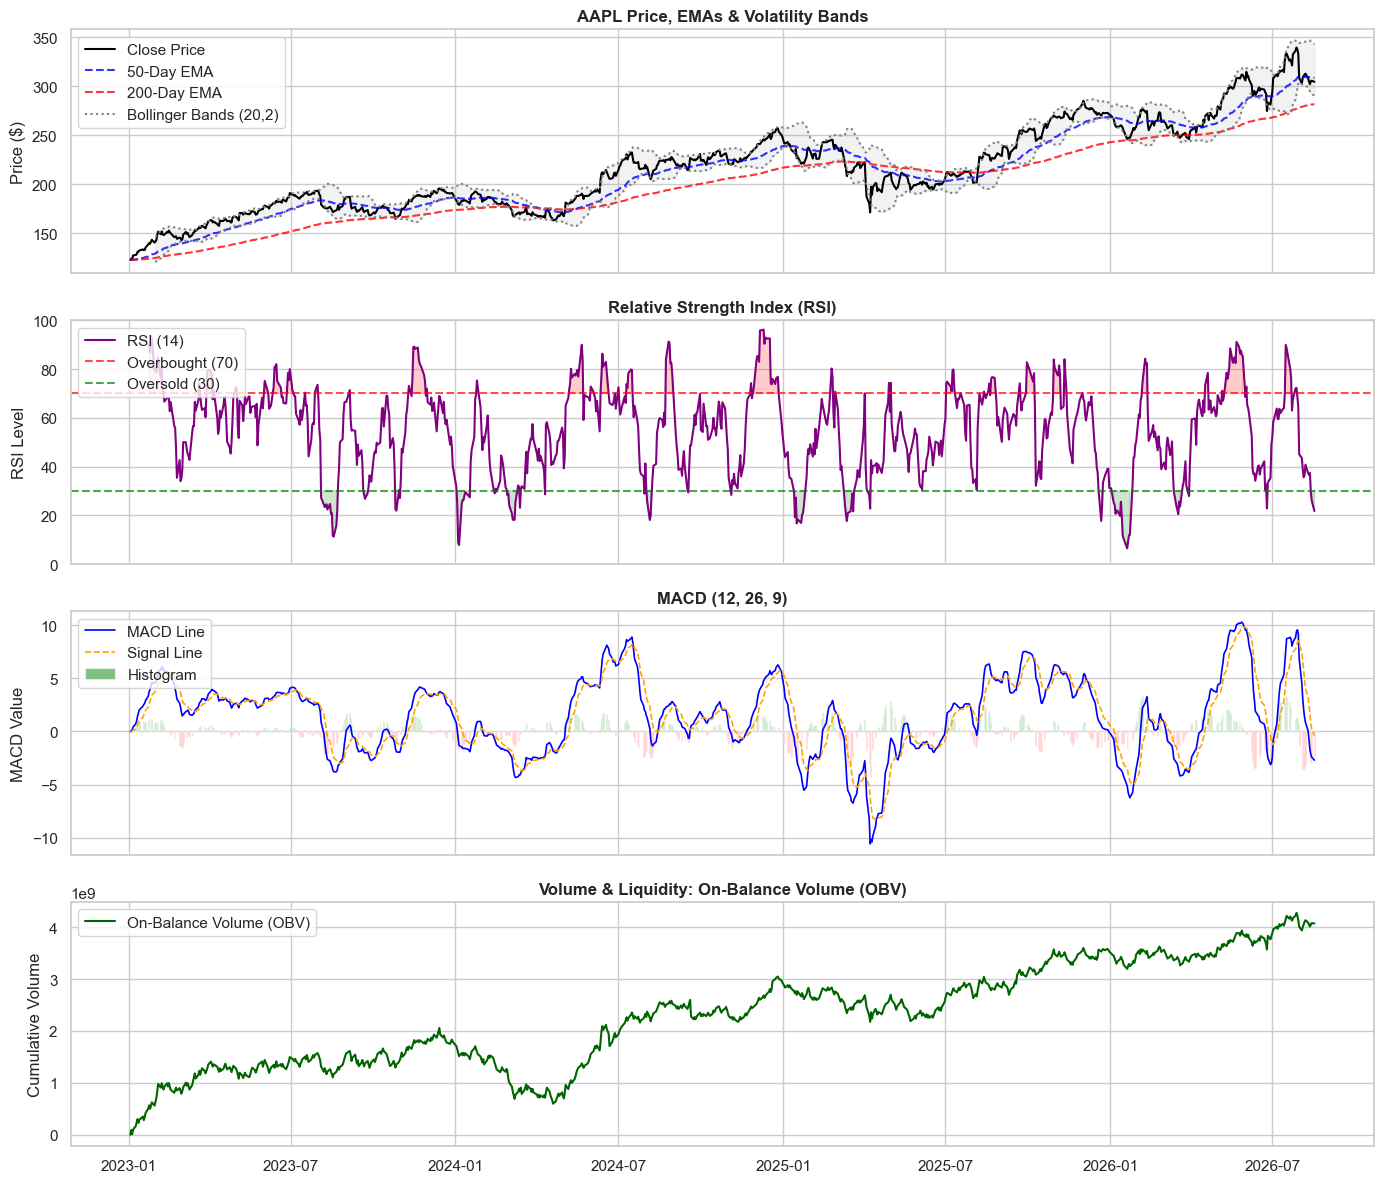

In [100]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 10)

# 1. DOWNLOAD TARGET EQUITY & VIX DATA
ticker_symbol = "AAPL"
vix_symbol = "^VIX"
start_date = "2023-01-01"

print(
    f"Fetching OHLCV data for {ticker_symbol} and Volatility Index ({vix_symbol})..."
)
raw_df = yf.download(
    [ticker_symbol, vix_symbol], start=start_date, auto_adjust=True
)

# Extract price/volume data for the target equity
if isinstance(raw_df.columns, pd.MultiIndex):
    df = pd.DataFrame(
        {
            "Open": raw_df["Open"][ticker_symbol],
            "High": raw_df["High"][ticker_symbol],
            "Low": raw_df["Low"][ticker_symbol],
            "Close": raw_df["Close"][ticker_symbol],
            "Volume": raw_df["Volume"][ticker_symbol],
        }
    )
    vix_close = raw_df["Close"][vix_symbol]
else:
    df = raw_df.copy()
    vix_close = pd.Series(dtype=float)

df = df.ffill().dropna()

# 2. TECHNICAL INDICATOR CALCULATIONS

# A. Trend Metrics: Exponential Moving Averages (EMA)
df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()
df["EMA_200"] = df["Close"].ewm(span=200, adjust=False).mean()

# B. Momentum Metrics: Relative Strength Index (RSI - 14 Period)
delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

# C. Trend Convergence: MACD (12, 26, 9)
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema_12 - ema_26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

# D. Volatility Indicators: Bollinger Bands (20-day, 2 Std Dev)
df["BB_Middle"] = df["Close"].rolling(window=20).mean()
df["BB_Std"] = df["Close"].rolling(window=20).std()
df["BB_Upper"] = df["BB_Middle"] + (2 * df["BB_Std"])
df["BB_Lower"] = df["BB_Middle"] - (2 * df["BB_Std"])

# E. Volume & Liquidity: On-Balance Volume (OBV)
obv_direction = np.where(
    df["Close"] > df["Close"].shift(1),
    1,
    np.where(df["Close"] < df["Close"].shift(1), -1, 0),
)
df["OBV"] = (df["Volume"] * obv_direction).cumsum()

# Add VIX Sentiment
df["VIX"] = vix_close

# 3. TECHNICAL & MICROSTRUCTURE DASHBOARD DISPLAY
latest = df.iloc[-1]
prev = df.iloc[-2]

# Technical Summary Table
summary_data = {
    "Metric": [
        "Price vs. 200-EMA Trend",
        "RSI (14-Day)",
        "MACD Signal State",
        "Bollinger Band Position",
        "On-Balance Volume (OBV)",
        "Market Volatility Index (VIX)",
    ],
    "Value": [
        f"${latest['Close']:.2f} (200-EMA: ${latest['EMA_200']:.2f})",
        f"{latest['RSI_14']:.1f}",
        f"{'Bullish' if latest['MACD'] > latest['MACD_Signal'] else 'Bearish'} (Hist: {latest['MACD_Hist']:.2f})",
        f"{'Upper Band Touch' if latest['Close'] >= latest['BB_Upper'] else 'Lower Band Touch' if latest['Close'] <= latest['BB_Lower'] else 'Inside Range'}",
        f"{latest['OBV']:,.0f}",
        f"{latest['VIX']:.2f}",
    ],
    "Interpretation": [
        (
            "Uptrend / Long-term Bullish"
            if latest["Close"] > latest["EMA_200"]
            else "Downtrend / Bearish"
        ),
        (
            "Overbought (>70)"
            if latest["RSI_14"] > 70
            else "Oversold (<30)" if latest["RSI_14"] < 30 else "Neutral Zone"
        ),
        (
            "Positive Momentum"
            if latest["MACD_Hist"] > 0
            else "Negative Momentum"
        ),
        (
            "High Volatility / Upper Threshold"
            if latest["Close"] >= latest["BB_Upper"]
            else "Low Volatility / Band Contraction"
        ),
        (
            "Accumulation (Buying Pressure)"
            if latest["OBV"] > prev["OBV"]
            else "Distribution (Selling Pressure)"
        ),
        (
            "Complacent / Low Risk"
            if latest["VIX"] < 15
            else "Elevated Market Stress" if latest["VIX"] > 20 else "Moderate"
        ),
    ],
}

print("=" * 80)
print(
    f"TECHNICAL & MARKET MICROSTRUCTURE ANALYSIS: {ticker_symbol} ({df.index[-1].strftime('%Y-%m-%d')})"
)
print("=" * 80)
display(pd.DataFrame(summary_data).set_index("Metric"))

# 4. MULTI-PANEL TECHNICAL CHARTING
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price, EMAs & Bollinger Bands
axes[0].plot(
    df.index,
    df["Close"],
    label="Close Price",
    color="black",
    linewidth=1.5,
)
axes[0].plot(
    df.index,
    df["EMA_50"],
    label="50-Day EMA",
    color="blue",
    linestyle="--",
    alpha=0.8,
)
axes[0].plot(
    df.index,
    df["EMA_200"],
    label="200-Day EMA",
    color="red",
    linestyle="--",
    alpha=0.8,
)
axes[0].plot(
    df.index,
    df["BB_Upper"],
    color="gray",
    linestyle=":",
    label="Bollinger Bands (20,2)",
)
axes[0].plot(df.index, df["BB_Lower"], color="gray", linestyle=":")
axes[0].fill_between(
    df.index,
    df["BB_Lower"],
    df["BB_Upper"],
    color="gray",
    alpha=0.1,
)
axes[0].set_title(
    f"{ticker_symbol} Price, EMAs & Volatility Bands",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_ylabel("Price ($)")
axes[0].legend(loc="upper left")

# Panel 2: RSI
axes[1].plot(
    df.index, df["RSI_14"], color="purple", linewidth=1.5, label="RSI (14)"
)
axes[1].axhline(70, color="red", linestyle="--", alpha=0.7, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.7, label="Oversold (30)")
axes[1].fill_between(
    df.index,
    y1=70,
    y2=df["RSI_14"],
    where=(df["RSI_14"] >= 70),
    color="red",
    alpha=0.2,
)
axes[1].fill_between(
    df.index,
    y1=30,
    y2=df["RSI_14"],
    where=(df["RSI_14"] <= 30),
    color="green",
    alpha=0.2,
)
axes[1].set_title("Relative Strength Index (RSI)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("RSI Level")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="upper left")

# Panel 3: MACD
axes[2].plot(
    df.index, df["MACD"], color="blue", linewidth=1.2, label="MACD Line"
)
axes[2].plot(
    df.index,
    df["MACD_Signal"],
    color="orange",
    linestyle="--",
    linewidth=1.2,
    label="Signal Line",
)
axes[2].bar(
    df.index,
    df["MACD_Hist"],
    color=np.where(df["MACD_Hist"] >= 0, "green", "red"),
    alpha=0.5,
    label="Histogram",
)
axes[2].set_title("MACD (12, 26, 9)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("MACD Value")
axes[2].legend(loc="upper left")

# Panel 4: On-Balance Volume (OBV)
axes[3].plot(
    df.index,
    df["OBV"],
    color="darkgreen",
    linewidth=1.5,
    label="On-Balance Volume (OBV)",
)
axes[3].set_title(
    "Volume & Liquidity: On-Balance Volume (OBV)",
    fontsize=12,
    fontweight="bold",
)
axes[3].set_ylabel("Cumulative Volume")
axes[3].legend(loc="upper left")

plt.tight_layout()
plt.show()

## 5. Structuring the Client Deliverable

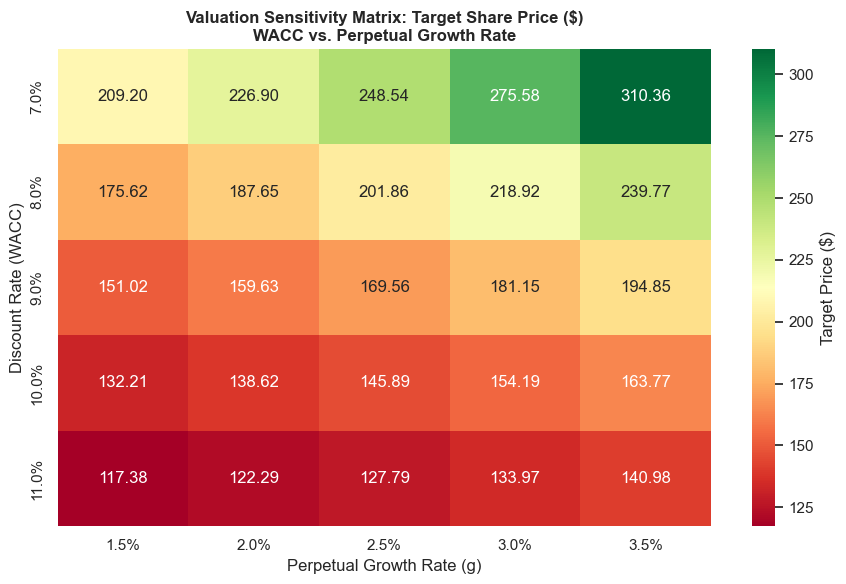

In [101]:
def generate_dcf_sensitivity(
    base_fcf,
    wacc_range,
    growth_range,
    net_debt,
    shares_outstanding,
    forecast_years=5,
):
    """Generates a intrinsic value per share sensitivity matrix for executive client reports."""
    matrix = np.zeros((len(wacc_range), len(growth_range)))

    for i, wacc in enumerate(wacc_range):
        for j, g in enumerate(growth_range):
            if wacc <= g:
                matrix[i, j] = np.nan
                continue

            # Project Explicit FCF (assuming baseline 5% FCF growth during explicit period)
            pv_explicit = sum(
                [
                    (base_fcf * (1.05 ** t)) / ((1 + wacc) ** t)
                    for t in range(1, forecast_years + 1)
                ]
            )

            # Terminal Value Calculation
            fcf_terminal = (base_fcf * (1.05 ** forecast_years)) * (1 + g)
            terminal_value = fcf_terminal / (wacc - g)
            pv_terminal = terminal_value / ((1 + wacc) ** forecast_years)

            # Enterprise Value to Equity Value per Share
            enterprise_value = pv_explicit + pv_terminal
            equity_value = enterprise_value - net_debt
            price_per_share = equity_value / shares_outstanding
            matrix[i, j] = price_per_share

    df_matrix = pd.DataFrame(
        matrix,
        index=[f"{w*100:.1f}%" for w in wacc_range],
        columns=[f"{g*100:.1f}%" for g in growth_range],
    )
    return df_matrix


# Client Valuation Inputs
base_fcf_m = 500.0  # $500M baseline FCF
net_debt_m = 300.0  # $300M Net Debt
shares_m = 50.0  # 50M shares outstanding

wacc_steps = np.linspace(0.07, 0.11, 5)  # 7.0% to 11.0% WACC
growth_steps = np.linspace(0.015, 0.035, 5)  # 1.5% to 3.5% Terminal Growth

# Generate Sensitivity Table
sensitivity_df = generate_dcf_sensitivity(
    base_fcf_m, wacc_steps, growth_steps, net_debt_m, shares_m
)

# Plot Sensitivity Heatmap for Executive Presentation
plt.figure(figsize=(9, 6))
sns.heatmap(
    sensitivity_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    cbar_kws={"label": "Target Price ($)"},
)
plt.title(
    "Valuation Sensitivity Matrix: Target Share Price ($)\nWACC vs. Perpetual Growth Rate",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Perpetual Growth Rate (g)")
plt.ylabel("Discount Rate (WACC)")
plt.tight_layout()
plt.show()